# Population Statistics

Compute and visualise statistics on all population files in `data/eqasim_output/`:
- Demographics (age, gender, CSP, household size)
- Mobility profile (activity purposes, transport accessibility)
- Activity timing (number of activities, gap between start times)
- Comparison with EMC² 2023 reference survey

In [ ]:
import json
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

REPO_ROOT = Path("../../../").resolve()
POP_DIR   = REPO_ROOT / "data" / "eqasim_output"

# File used for EMC² comparison (single file to avoid double-counting)
COMPARE_FILE = "toulouse_population_400.json"

print(f"REPO_ROOT: {REPO_ROOT}")
print(f"POP_DIR:   {POP_DIR}")

In [ ]:
all_data: dict[str, list] = {}

for p in sorted(POP_DIR.glob("toulouse_population_*.json")):
    with open(p, encoding="utf-8") as f:
        all_data[p.name] = json.load(f)

print(f"Loaded {len(all_data)} population files:")
for fname, data in all_data.items():
    print(f"  {fname}  ({len(data)} persons)")

## Section 7 — Statistics

In [61]:
CSP_LABELS = {
    1: "Agriculteurs",
    2: "Artisans/Comm.",
    3: "Cadres",
    4: "Prof. interm.",
    5: "Employés",
    6: "Ouvriers",
    7: "Retraités",
    8: "Inactifs",
}

def compute_stats(data: list, fname: str) -> pd.DataFrame:
    rows = []
    for entry in data:
        identity   = entry.get("identity", {})
        traits     = identity.get("traits_json", {})
        acts_all   = identity.get("activities", [])
        inner_count = max(0, len(acts_all) - 2)
        purposes   = [a.get("purpose") for a in acts_all]
        home       = identity.get("home")
        pt_access  = bool(home and home.get("public_transport", False))
        rows.append({
            "file":            fname,
            "person_id":       entry.get("person_id"),
            "age":             traits.get("age"),
            "gender":          traits.get("gender"),
            "csp":             traits.get("socioprofessional_category"),
            "income":          traits.get("income_bracket"),
            "cars":            traits.get("number_of_cars", 0),
            "household_size":  traits.get("household_size"),
            "is_llm":          entry.get("is_llm_based", True),
            "n_acts_total":    len(acts_all),
            "n_inner_acts":    inner_count,
            "has_work":        "work" in purposes,
            "has_education":   "education" in purposes,
            "has_leisure":     "leisure" in purposes,
            "has_shopping":    "shop" in purposes,
            "has_other":       "other" in purposes,
            "pt_accessible":   pt_access,
        })
    return pd.DataFrame(rows)

all_dfs = [compute_stats(data, fname) for fname, data in all_data.items()]
combined_df = pd.concat(all_dfs, ignore_index=True)

summary = combined_df.groupby("file").agg(
    n_people=("person_id", "count"),
    avg_age=("age", "mean"),
    pct_male=("gender", lambda x: round((x == "Male").mean() * 100, 1)),
    avg_inner_acts=("n_inner_acts", "mean"),
    avg_acts_total=("n_acts_total", "mean"),
    pct_car=("cars", lambda x: round((x > 0).mean() * 100, 1)),
    pct_pt=("pt_accessible", lambda x: round(x.mean() * 100, 1)),
    pct_work=("has_work", lambda x: round(x.mean() * 100, 1)),
    pct_edu=("has_education", lambda x: round(x.mean() * 100, 1)),
    pct_other=("has_other", lambda x: round(x.mean() * 100, 1)),
    pct_llm=("is_llm", lambda x: round(x.mean() * 100, 1)),
).round(2)

print("\n=== Per-file summary ===")
display(summary)
print(f"\nTotal rows: {len(combined_df)}  —  unique person_ids: {combined_df['person_id'].nunique()}")


=== Per-file summary ===


,n_people,avg_age,pct_male,avg_inner_acts,avg_acts_total,pct_car,pct_pt,pct_work,pct_edu,pct_other,pct_llm
file,,,,,,,,,,,
toulouse_population_100.json,108,39.34,46.3,1.77,3.77,85.2,75.9,50.9,6.5,26.9,100.0
toulouse_population_200.json,1988,40.80,48.2,1.72,3.72,85.5,78.7,54.0,5.8,30.5,100.0
toulouse_population_300.json,1988,40.80,48.2,1.72,3.72,85.5,78.7,54.0,5.8,30.5,100.0
toulouse_population_400.json,1021,41.22,48.6,1.86,3.86,87.0,79.7,53.5,4.1,31.6,100.0
toulouse_population_50.json,483,39.32,48.7,1.98,3.98,88.4,78.5,52.2,4.6,31.5,100.0
toulouse_population_500.json,483,39.32,48.7,1.98,3.98,88.4,78.5,52.2,4.6,31.5,100.0
toulouse_population_600.json,623,40.44,49.1,1.71,3.71,87.3,80.7,52.6,5.0,31.9,100.0



Total rows: 6694  —  unique person_ids: 2132


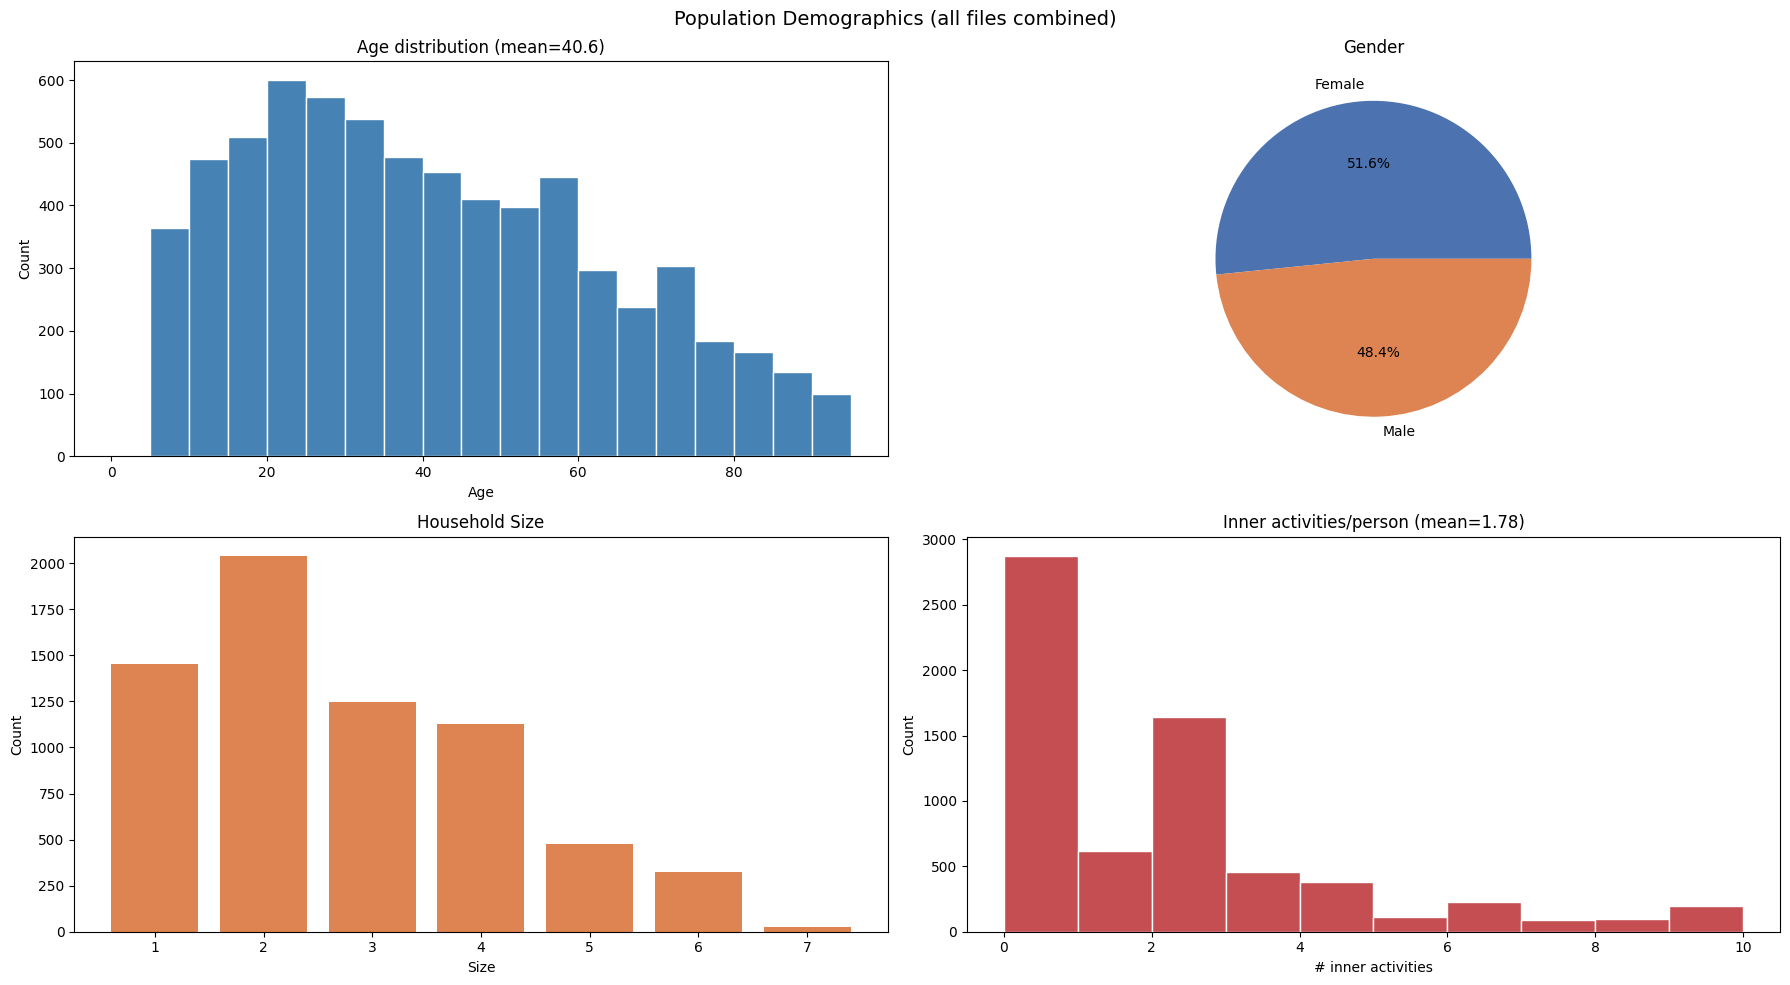

In [62]:
# ── Demographic charts ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle("Population Demographics (all files combined)", fontsize=14)

# Age
ax = axes[0, 0]
ages = combined_df["age"].dropna()
ax.hist(ages, bins=range(0, 100, 5), edgecolor="white", color="steelblue")
ax.set_title(f"Age distribution (mean={ages.mean():.1f})")
ax.set_xlabel("Age"); ax.set_ylabel("Count")

# Gender
ax = axes[0, 1]
gc = combined_df["gender"].value_counts()
ax.pie(gc.values, labels=gc.index, autopct="%1.1f%%",
       colors=["#4C72B0", "#DD8452", "#55A868"])
ax.set_title("Gender")

# # CSP
# ax = axes[0, 2]
# csp_counts = combined_df["csp"].value_counts().sort_index()
# labels = [CSP_LABELS.get(int(k), str(k)) if pd.notna(k) else "?" for k in csp_counts.index]
# ax.barh(labels, csp_counts.values, color="#4C72B0")
# ax.set_title("Socioprofessional Category (CSP)")
# ax.set_xlabel("Count")

# # Income
# ax = axes[1, 0]
# ic = combined_df["income"].value_counts().sort_index()
# ax.bar(ic.index.astype(str), ic.values, color="#55A868")
# ax.set_title("Income Bracket")
# ax.set_xlabel("Bracket"); ax.set_ylabel("Count")
# plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

# Household size
ax = axes[1, 0]
hs = combined_df["household_size"].value_counts().sort_index()
ax.bar(hs.index.astype(str), hs.values, color="#DD8452")
ax.set_title("Household Size")
ax.set_xlabel("Size"); ax.set_ylabel("Count")

# Inner activities
ax = axes[1, 1]
ia = combined_df["n_inner_acts"]
ax.hist(ia, bins=range(0, int(ia.max()) + 2), edgecolor="white", color="#C44E52")
ax.set_title(f"Inner activities/person (mean={ia.mean():.2f})")
ax.set_xlabel("# inner activities"); ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

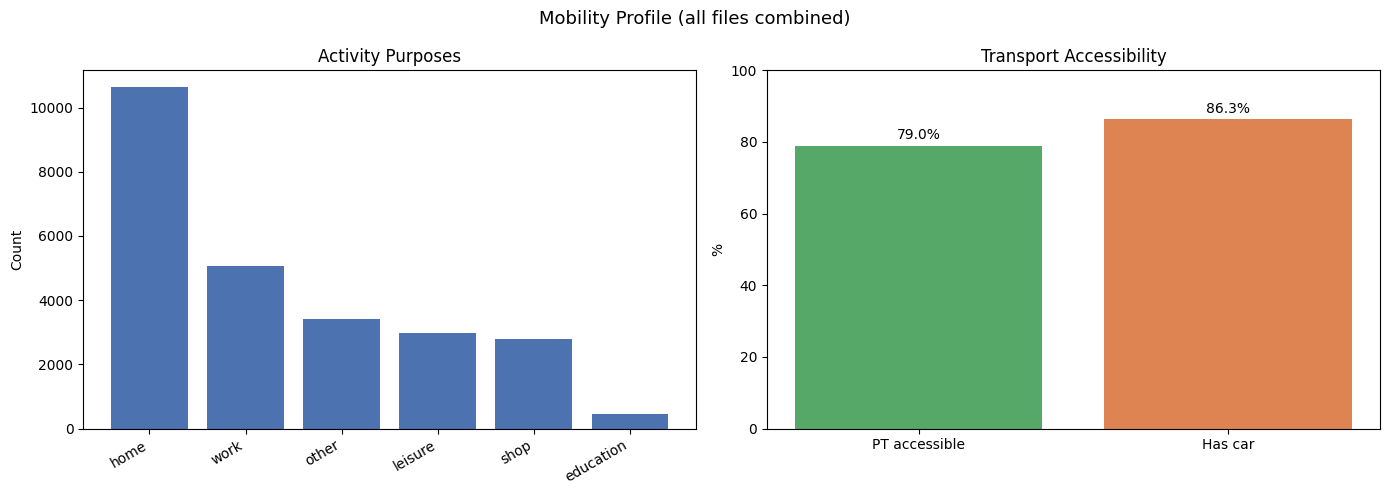

In [63]:
# ── Mobility charts ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Mobility Profile (all files combined)", fontsize=13)

# Activity purposes (all activities, including "other")
ax = axes[0]
purpose_counts: dict[str, int] = defaultdict(int)
for fname, data in all_data.items():
    for entry in data:
        for act in entry.get("identity", {}).get("activities", []):
            purpose_counts[act.get("purpose", "?")] += 1
ps = pd.Series(purpose_counts).sort_values(ascending=False)
ax.bar(ps.index, ps.values, color="#4C72B0")
ax.set_title("Activity Purposes")
ax.set_ylabel("Count")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

# Transport accessibility
ax = axes[1]
pt_pct  = combined_df["pt_accessible"].mean() * 100
car_pct = (combined_df["cars"] > 0).mean() * 100
bars = ax.bar(["PT accessible", "Has car"], [pt_pct, car_pct],
              color=["#55A868", "#DD8452"])
ax.set_ylim(0, 100)
ax.set_ylabel("%")
ax.set_title("Transport Accessibility")
for bar, val in zip(bars, [pt_pct, car_pct]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{val:.1f}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [64]:
# ── Detailed per-file printed stats ──────────────────────────────────────────
for fname in combined_df["file"].unique():
    sub = combined_df[combined_df["file"] == fname]
    print(f"\n{'='*60}")
    print(f"FILE: {fname}")
    print(f"{'='*60}")
    print(f"  People              : {len(sub)}")
    print(f"  Unique person IDs   : {sub['person_id'].nunique()}")
    print(f"  Age  mean±std       : {sub['age'].mean():.1f} ± {sub['age'].std():.1f}")
    print(f"  Age  range          : [{sub['age'].min():.0f}, {sub['age'].max():.0f}]")
    print(f"  Male                : {(sub['gender']=='Male').mean()*100:.1f}%")
    print(f"  Has car             : {(sub['cars']>0).mean()*100:.1f}%")
    print(f"  PT accessible       : {sub['pt_accessible'].mean()*100:.1f}%")
    print(f"  Avg inner acts      : {sub['n_inner_acts'].mean():.2f}")
    print(f"  Has work trip       : {sub['has_work'].mean()*100:.1f}%")
    print(f"  Has education trip  : {sub['has_education'].mean()*100:.1f}%")
    print(f"  Has other trip      : {sub['has_other'].mean()*100:.1f}%")
    print(f"  Is LLM-based        : {sub['is_llm'].mean()*100:.1f}%")
    print("  CSP distribution:")
    for csp_val, cnt in sub["csp"].value_counts().sort_index().items():
        label = CSP_LABELS.get(int(csp_val), str(csp_val)) if pd.notna(csp_val) else "?"
        print(f"    {label:<22}: {cnt:4d} ({cnt/len(sub)*100:.1f}%)")


FILE: toulouse_population_100.json
  People              : 108
  Unique person IDs   : 108
  Age  mean±std       : 39.3 ± 22.5
  Age  range          : [5, 88]
  Male                : 46.3%
  Has car             : 85.2%
  PT accessible       : 75.9%
  Avg inner acts      : 1.77
  Has work trip       : 50.9%
  Has education trip  : 6.5%
  Has other trip      : 26.9%
  Is LLM-based        : 100.0%
  CSP distribution:

FILE: toulouse_population_200.json
  People              : 1988
  Unique person IDs   : 1988
  Age  mean±std       : 40.8 ± 22.7
  Age  range          : [5, 99]
  Male                : 48.2%
  Has car             : 85.5%
  PT accessible       : 78.7%
  Avg inner acts      : 1.72
  Has work trip       : 54.0%
  Has education trip  : 5.8%
  Has other trip      : 30.5%
  Is LLM-based        : 100.0%
  CSP distribution:

FILE: toulouse_population_300.json
  People              : 1988
  Unique person IDs   : 1988
  Age  mean±std       : 40.8 ± 22.7
  Age  range          : [5, 99

## Section 7b — Activités : nombre moyen et délai minimum entre démarrages

=== Activités : nombre et délais entre démarrages ===
(tous les délais sont en minutes)



,nb_actes_moyen,nb_actes_écart-type,délai_moyen_min,délai_médian_min,min_gap_moy/pers_min,min_gap_p10_min,min_gap_absolu_min
file,,,,,,,
toulouse_population_100.json,3.8,2.3,-97.0,30.0,-501.9,-765.0,-1019.2
toulouse_population_200.json,3.7,2.2,-95.2,25.0,-489.0,-750.0,-1045.5
toulouse_population_300.json,3.7,2.2,-95.2,25.0,-489.0,-750.0,-1045.5
toulouse_population_400.json,3.9,2.3,-90.9,25.0,-498.1,-750.0,-1049.7
toulouse_population_50.json,4.0,2.3,-78.2,28.0,-489.7,-735.0,-1045.0
toulouse_population_500.json,4.0,2.3,-78.4,28.0,-490.3,-735.0,-1045.0
toulouse_population_600.json,3.7,2.1,-93.1,24.0,-491.4,-758.0,-1047.3



  toulouse_population_100.json
    Nb activités/pers    : 3.77 ± 2.29
    Délai moyen          : -97.0 min
    Délai médian         : 30.0 min
    Délai min moyen/pers : -501.9 min  (p10=-765.0 min)
    Délai min absolu     : -1019.2 min

  toulouse_population_200.json
    Nb activités/pers    : 3.72 ± 2.21
    Délai moyen          : -95.2 min
    Délai médian         : 25.0 min
    Délai min moyen/pers : -489.0 min  (p10=-750.0 min)
    Délai min absolu     : -1045.5 min

  toulouse_population_300.json
    Nb activités/pers    : 3.72 ± 2.21
    Délai moyen          : -95.2 min
    Délai médian         : 25.0 min
    Délai min moyen/pers : -489.0 min  (p10=-750.0 min)
    Délai min absolu     : -1045.5 min

  toulouse_population_400.json
    Nb activités/pers    : 3.86 ± 2.34
    Délai moyen          : -90.9 min
    Délai médian         : 25.0 min
    Délai min moyen/pers : -498.1 min  (p10=-750.0 min)
    Délai min absolu     : -1049.7 min

  toulouse_population_50.json
    Nb activi

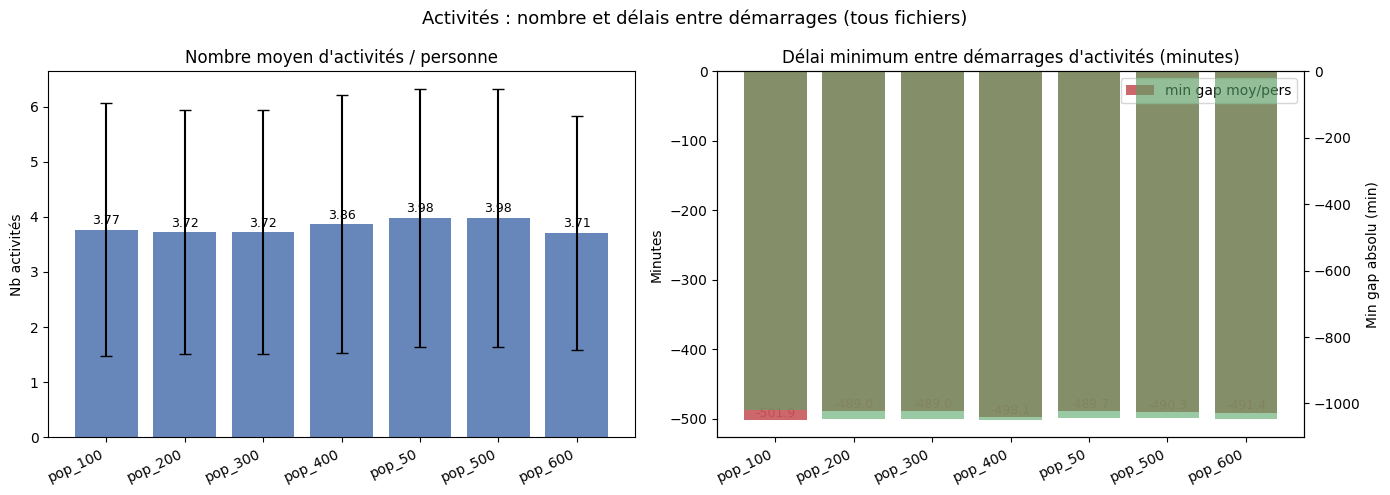

In [65]:
# ── Par fichier : nombre moyen d'activités et délai minimum entre démarrages ──

def activity_timing_stats(data: list) -> dict:
    """
    Pour chaque personne, calcule :
      - n_acts  : nombre total d'activités
      - min_gap : délai minimum (secondes) entre les start_time de deux activités consécutives
    Retourne des statistiques agrégées sur l'ensemble du fichier.
    """
    n_acts_list  = []
    min_gaps     = []   # un min_gap par personne (uniquement si ≥ 2 activités)
    all_gaps     = []   # tous les gaps individuels (pour la distribution globale)

    for entry in data:
        acts = entry.get("identity", {}).get("activities", [])
        n_acts_list.append(len(acts))

        start_times = [
            a["start_time"] for a in acts
            if a.get("start_time") is not None
        ]
        if len(start_times) >= 2:
            gaps = [
                start_times[i + 1] - start_times[i]
                for i in range(len(start_times) - 1)
            ]
            min_gaps.append(min(gaps))
            all_gaps.extend(gaps)

    n_acts_arr = np.array(n_acts_list)
    min_gaps_arr = np.array(min_gaps) if min_gaps else np.array([float("nan")])
    all_gaps_arr = np.array(all_gaps) if all_gaps else np.array([float("nan")])

    return {
        "avg_n_acts":         n_acts_arr.mean(),
        "std_n_acts":         n_acts_arr.std(),
        "min_gap_global_s":   all_gaps_arr.min(),        # délai min absolu sur tous les gaps
        "avg_min_gap_s":      min_gaps_arr.mean(),       # moyenne des mins par personne
        "p10_min_gap_s":      np.percentile(min_gaps_arr, 10),
        "median_gap_s":       np.median(all_gaps_arr),
        "avg_gap_s":          all_gaps_arr.mean(),
    }

timing_rows = []
for fname, data in all_data.items():
    stats = activity_timing_stats(data)
    stats["file"] = fname
    timing_rows.append(stats)

timing_df = pd.DataFrame(timing_rows).set_index("file")

# Convertir secondes → minutes pour la lisibilité
for col in ["min_gap_global_s", "avg_min_gap_s", "p10_min_gap_s", "median_gap_s", "avg_gap_s"]:
    timing_df[col.replace("_s", "_min")] = (timing_df[col] / 60).round(1)

display_cols = [
    "avg_n_acts", "std_n_acts",
    "avg_gap_min", "median_gap_min",
    "avg_min_gap_min", "p10_min_gap_min", "min_gap_global_min",
]
print("=== Activités : nombre et délais entre démarrages ===")
print("(tous les délais sont en minutes)\n")
display(timing_df[display_cols].rename(columns={
    "avg_n_acts":          "nb_actes_moyen",
    "std_n_acts":          "nb_actes_écart-type",
    "avg_gap_min":         "délai_moyen_min",
    "median_gap_min":      "délai_médian_min",
    "avg_min_gap_min":     "min_gap_moy/pers_min",
    "p10_min_gap_min":     "min_gap_p10_min",
    "min_gap_global_min":  "min_gap_absolu_min",
}).round(1))

# ── Détail textuel par fichier ─────────────────────────────────────────────────
print()
for fname, row in timing_df.iterrows():
    print(f"  {fname}")
    print(f"    Nb activités/pers    : {row['avg_n_acts']:.2f} ± {row['std_n_acts']:.2f}")
    print(f"    Délai moyen          : {row['avg_gap_min']:.1f} min")
    print(f"    Délai médian         : {row['median_gap_min']:.1f} min")
    print(f"    Délai min moyen/pers : {row['avg_min_gap_min']:.1f} min  (p10={row['p10_min_gap_min']:.1f} min)")
    print(f"    Délai min absolu     : {row['min_gap_global_min']:.1f} min")
    print()

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Activités : nombre et délais entre démarrages (tous fichiers)", fontsize=13)

fnames_short = [f.replace("toulouse_population_", "pop_").replace(".json", "")
                for f in timing_df.index]

# Graphique 1 — Nombre moyen d'activités par personne
ax = axes[0]
bars = ax.bar(fnames_short, timing_df["avg_n_acts"], color="#4C72B0", alpha=0.85)
ax.errorbar(fnames_short, timing_df["avg_n_acts"],
            yerr=timing_df["std_n_acts"], fmt="none", color="black", capsize=4)
ax.set_title("Nombre moyen d'activités / personne")
ax.set_ylabel("Nb activités")
plt.setp(ax.get_xticklabels(), rotation=25, ha="right")
for bar, val in zip(bars, timing_df["avg_n_acts"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f"{val:.2f}", ha="center", va="bottom", fontsize=9)

# Graphique 2 — Délai minimum moyen entre démarrages (par personne)
ax = axes[1]
bars2 = ax.bar(fnames_short, timing_df["avg_min_gap_min"], color="#C44E52", alpha=0.85,
               label="min gap moy/pers")
ax2 = ax.twinx()
bars3 = ax2.bar(fnames_short, timing_df["min_gap_global_min"], color="#55A868", alpha=0.6,
               label="min gap absolu")
ax2.set_ylabel("Min gap absolu (min)")
ax.set_title("Délai minimum entre démarrages d'activités (minutes)")
ax.set_ylabel("Minutes")
ax.legend()
plt.setp(ax.get_xticklabels(), rotation=25, ha="right")
for bar, val in zip(bars2, timing_df["avg_min_gap_min"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{val:.1f}", ha="center", va="bottom", fontsize=9, color="#C44E52")

plt.tight_layout()
plt.show()

Comparing 'toulouse_population_400.json' (1021 persons) against EMC² 2023 reference


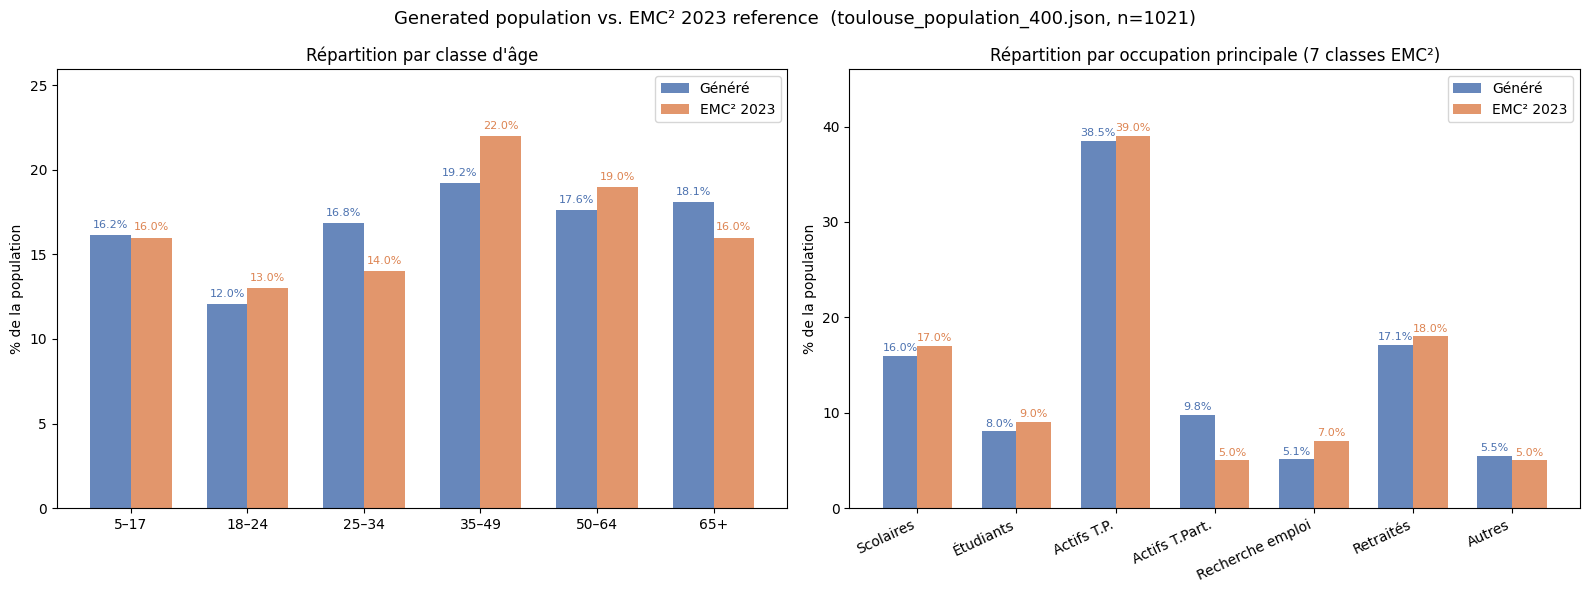


Age deltas (Généré − EMC²):
  5–17    : +0.2 pp
  18–24   : -1.0 pp
  25–34   : +2.8 pp
  35–49   : -2.8 pp
  50–64   : -1.4 pp
  65+     : +2.1 pp

Occupation deltas (Généré − EMC²):
  Scolaires           : -1.0 pp
  Étudiants           : -1.0 pp
  Actifs T.P.         : -0.5 pp
  Actifs T.Part.      : +4.8 pp
  Recherche emploi    : -1.9 pp
  Retraités           : -0.9 pp
  Autres              : +0.5 pp


In [66]:
import yaml

# ── Load EMC² 2023 reference ───────────────────────────────────────────────────
ref_path = REPO_ROOT / "scripts" / "data" / "population" / "population_emc2_2023.yaml"
with open(ref_path, encoding="utf-8") as f:
    ref = yaml.safe_load(f)

ref_age_pct = ref["enquete"]["repartition_par_classe_age"]
ref_occ_raw = ref["enquete"]["repartition_par_occupation_principale"]

# ── Pick largest single file for comparison (avoids double-counting) ──────────
COMPARE_FILE = "toulouse_population_400.json"
df_cmp = combined_df[combined_df["file"] == COMPARE_FILE].copy()
print(f"Comparing '{COMPARE_FILE}' ({len(df_cmp)} persons) against EMC² 2023 reference")

# ── Age bins matching EMC² buckets ─────────────────────────────────────────────
age_bins   = [5,  18,  25,  35,  50,  65, 200]
age_labels = ["5–17", "18–24", "25–34", "35–49", "50–64", "65+"]

df_cmp["age_group"] = pd.cut(
    df_cmp["age"].clip(lower=5),
    bins=age_bins, right=False, labels=age_labels,
)
gen_age_pct = df_cmp["age_group"].value_counts(normalize=True).reindex(age_labels) * 100

ref_age_series = pd.Series({
    "5–17":  ref_age_pct["5-17_ans"],
    "18–24": ref_age_pct["18-24_ans"],
    "25–34": ref_age_pct["25-34_ans"],
    "35–49": ref_age_pct["35-49_ans"],
    "50–64": ref_age_pct["50-64_ans"],
    "65+":   ref_age_pct["65_ans_et_plus"],
}, name="EMC² 2023").astype(float)

# ── Occupation mapping (7 classes EMC²) ───────────────────────────────────────
# Champs disponibles dans traits_json : main_occupation (FR), professional_activity (EN),
# age, employed, studies. employment_sector n'est renseigné que pour les actifs.

EMC2_OCC_CLASSES = [
    "scolaires_jusqu_au_bac",
    "etudiants",
    "actifs_temps_plein",
    "actifs_temps_partiel",
    "en_recherche_emploi",
    "retraites",
    "autres",
]
EMC2_OCC_LABELS = {
    "scolaires_jusqu_au_bac": "Scolaires",
    "etudiants":              "Étudiants",
    "actifs_temps_plein":     "Actifs T.P.",
    "actifs_temps_partiel":   "Actifs T.Part.",
    "en_recherche_emploi":    "Recherche emploi",
    "retraites":              "Retraités",
    "autres":                 "Autres",
}

_MAIN_OCC_MAP = {
    "Scolaire (jusqu'au Bac)":     "scolaires_jusqu_au_bac",
    "Étudiant":                    "etudiants",
    "Travail à plein temps":       "actifs_temps_plein",
    "Travail à temps partiel":     "actifs_temps_partiel",
    "Chômeur/recherche d'emploi":  "en_recherche_emploi",
    "Retraité":                    "retraites",
    "Personne au foyer":           "autres",
}
_PROF_ACT_MAP = {
    "Full-Time Worker": "actifs_temps_plein",
    "Part-Time Worker": "actifs_temps_partiel",
    "Retired":          "retraites",
    "Unemployed":       "en_recherche_emploi",
    "Child (under 14)": "scolaires_jusqu_au_bac",
    "Homemaker":        "autres",
    "Other Inactive":   "autres",
}

def map_occupation_emc2(traits: dict) -> str:
    main_occ = traits.get("main_occupation", "")
    prof_act = traits.get("professional_activity", "")
    age      = traits.get("age", 99)
    if main_occ in _MAIN_OCC_MAP:
        return _MAIN_OCC_MAP[main_occ]
    if prof_act == "Student":
        return "scolaires_jusqu_au_bac" if age < 18 else "etudiants"
    if prof_act in _PROF_ACT_MAP:
        return _PROF_ACT_MAP[prof_act]
    if traits.get("employed"):
        return "actifs_temps_plein"
    if traits.get("studies"):
        return "scolaires_jusqu_au_bac" if age < 18 else "etudiants"
    if age >= 60:
        return "retraites"
    return "autres"

# Compute from all_data (traits_json not in combined_df)
occ_raw_data = all_data[COMPARE_FILE]
occ_counts: dict[str, int] = {c: 0 for c in EMC2_OCC_CLASSES}
for entry in occ_raw_data:
    cls = map_occupation_emc2(entry["identity"]["traits_json"])
    occ_counts[cls] += 1

n_total = sum(occ_counts.values())
gen_occ_pct = pd.Series(
    {c: occ_counts[c] / n_total * 100 for c in EMC2_OCC_CLASSES},
    name="Généré",
)
ref_occ_series = pd.Series(
    {c: ref_occ_raw[c] for c in EMC2_OCC_CLASSES},
    name="EMC² 2023",
).astype(float)

# ── Side-by-side comparison charts ────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    f"Generated population vs. EMC² 2023 reference  ({COMPARE_FILE}, n={n_total})",
    fontsize=13,
)

BAR_W = 0.35
COLOR_GEN = "#4C72B0"
COLOR_REF = "#DD8452"

# — Chart 1: Age distribution —
x1 = np.arange(len(age_labels))
b1a = ax1.bar(x1 - BAR_W/2, gen_age_pct.values,    BAR_W, label="Généré",    color=COLOR_GEN, alpha=0.85)
b1b = ax1.bar(x1 + BAR_W/2, ref_age_series.values,  BAR_W, label="EMC² 2023", color=COLOR_REF, alpha=0.85)
ax1.set_xticks(x1); ax1.set_xticklabels(age_labels)
ax1.set_ylabel("% de la population")
ax1.set_title("Répartition par classe d'âge")
ax1.legend()
ax1.set_ylim(0, max(gen_age_pct.max(), ref_age_series.max()) * 1.18)
for b in b1a:
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
             f"{b.get_height():.1f}%", ha="center", va="bottom", fontsize=8, color=COLOR_GEN)
for b in b1b:
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
             f"{b.get_height():.1f}%", ha="center", va="bottom", fontsize=8, color=COLOR_REF)

# — Chart 2: Occupation (7 classes EMC²) —
x2     = np.arange(len(EMC2_OCC_CLASSES))
labels = [EMC2_OCC_LABELS[c] for c in EMC2_OCC_CLASSES]
b2a = ax2.bar(x2 - BAR_W/2, gen_occ_pct.values,   BAR_W, label="Généré",    color=COLOR_GEN, alpha=0.85)
b2b = ax2.bar(x2 + BAR_W/2, ref_occ_series.values, BAR_W, label="EMC² 2023", color=COLOR_REF, alpha=0.85)
ax2.set_xticks(x2); ax2.set_xticklabels(labels, rotation=25, ha="right")
ax2.set_ylabel("% de la population")
ax2.set_title("Répartition par occupation principale (7 classes EMC²)")
ax2.legend()
ax2.set_ylim(0, max(gen_occ_pct.max(), ref_occ_series.max()) * 1.18)
for b in b2a:
    ax2.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
             f"{b.get_height():.1f}%", ha="center", va="bottom", fontsize=8, color=COLOR_GEN)
for b in b2b:
    ax2.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
             f"{b.get_height():.1f}%", ha="center", va="bottom", fontsize=8, color=COLOR_REF)

plt.tight_layout()
plt.show()

# ── Numeric deltas ─────────────────────────────────────────────────────────────
print("\nAge deltas (Généré − EMC²):")
for lbl in age_labels:
    delta = gen_age_pct[lbl] - ref_age_series[lbl]
    print(f"  {lbl:<8}: {delta:+.1f} pp")

print("\nOccupation deltas (Généré − EMC²):")
for cls in EMC2_OCC_CLASSES:
    delta = gen_occ_pct[cls] - ref_occ_series[cls]
    print(f"  {EMC2_OCC_LABELS[cls]:<20}: {delta:+.1f} pp")

## Section 8 — Comparison with EMC² 2023 Reference

In [67]:
import yaml

# ── EMC² 7 occupation classes ──────────────────────────────────────────────────
EMC2_OCC_CLASSES = [
    "scolaires_jusqu_au_bac",
    "etudiants",
    "actifs_temps_plein",
    "actifs_temps_partiel",
    "en_recherche_emploi",
    "retraites",
    "autres",
]

# ── Mapping: main_occupation (FR) → classe EMC² ───────────────────────────────
MAIN_OCC_MAPPING: dict[str, str] = {
    "Scolaire (jusqu'au Bac)":     "scolaires_jusqu_au_bac",
    "Étudiant":                    "etudiants",
    "Travail à plein temps":       "actifs_temps_plein",
    "Travail à temps partiel":     "actifs_temps_partiel",
    "Chômeur/recherche d'emploi":  "en_recherche_emploi",
    "Retraité":                    "retraites",
    "Personne au foyer":           "autres",
}

# ── Mapping: professional_activity (EN) → classe EMC² (fallback) ──────────────
# Note: "Student" can be scolaire or étudiant depending on age — age check below
PROF_ACT_MAPPING: dict[str, str] = {
    "Full-Time Worker":  "actifs_temps_plein",
    "Part-Time Worker":  "actifs_temps_partiel",
    "Retired":           "retraites",
    "Unemployed":        "en_recherche_emploi",
    "Child (under 14)":  "scolaires_jusqu_au_bac",
    "Homemaker":         "autres",
    "Other Inactive":    "autres",
    # "Student" handled with age check below
}

# ── Mapping: employment_sector → label lisible (pour affichage des actifs) ────
EMPLOYMENT_SECTOR_LABELS: dict[str, str] = {
    "public_admin_education_health":         "Admin. pub. / Éducation / Santé",
    "scientific_technical_support_services": "Sci. tech. / Services aux entr.",
    "retail_auto":                           "Commerce / Auto",
    "construction":                          "Construction / BTP",
    "information_communication":             "Info. / Communication",
    "arts_recreation_other_services":        "Arts / Loisirs / Autres services",
    "transport_storage":                     "Transport / Entreposage",
    "finance_insurance":                     "Finance / Assurance",
    "other_manufacturing":                   "Industrie diverse",
    "accommodation_food_services":           "Hôtellerie / Restauration",
    "transport_equipment":                   "Équipement de transport",
    "agriculture":                           "Agriculture",
    "real_estate":                           "Immobilier",
    "electrical_electronics_ict_machinery":  "Électronique / Machines",
    "energy_water_waste_mining":             "Énergie / Eau / Mines",
    "food_beverages_tobacco":                "Agro-alimentaire / Tabac",
}


def map_occupation_emc2(traits: dict) -> str:
    """
    Classifie un individu dans l'une des 7 classes d'occupation EMC² 2023.

    Priorité :
      1. main_occupation (FR) — champ le plus direct
      2. professional_activity (EN) — fallback avec règle age pour 'Student'
      3. Règles sur employed / studies / age — dernier recours
    """
    main_occ  = traits.get("main_occupation", "")
    prof_act  = traits.get("professional_activity", "")
    age       = traits.get("age", 99)
    employed  = traits.get("employed", False)
    studies   = traits.get("studies", False)

    # 1. main_occupation direct mapping
    if main_occ in MAIN_OCC_MAPPING:
        return MAIN_OCC_MAPPING[main_occ]

    # 2. professional_activity fallback
    if prof_act == "Student":
        return "scolaires_jusqu_au_bac" if age < 18 else "etudiants"
    if prof_act in PROF_ACT_MAPPING:
        return PROF_ACT_MAPPING[prof_act]

    # 3. Règles sur employed / studies / age
    if employed:
        return "actifs_temps_plein"   # pas de distinction PT/FT sans prof_act
    if studies:
        return "scolaires_jusqu_au_bac" if age < 18 else "etudiants"
    if age >= 60:
        return "retraites"

    return "autres"


# ── Test rapide sur un échantillon ────────────────────────────────────────────
sample_data = all_data[COMPARE_FILE]

occ_counts: dict[str, int] = {c: 0 for c in EMC2_OCC_CLASSES}
unknown: list[dict] = []

for entry in sample_data:
    t   = entry["identity"]["traits_json"]
    cls = map_occupation_emc2(t)
    if cls in occ_counts:
        occ_counts[cls] += 1
    else:
        unknown.append(t)

total = sum(occ_counts.values())
print(f"Classification de {total} personnes ({sample_file})\n")
print(f"{'Classe EMC²':<30} {'N':>5}  {'%':>6}")
print("-" * 44)
for cls in EMC2_OCC_CLASSES:
    n = occ_counts[cls]
    print(f"  {cls:<28} {n:>5}  {n/total*100:>5.1f}%")

if unknown:
    print(f"\n⚠ {len(unknown)} personnes non classifiées")
    for t in unknown[:3]:
        print(f"  main_occ={t.get('main_occupation')!r}  "
              f"prof_act={t.get('professional_activity')!r}  "
              f"age={t.get('age')}")

Classification de 1021 personnes (toulouse_population_1000.json)

Classe EMC²                        N       %
--------------------------------------------
  scolaires_jusqu_au_bac         163   16.0%
  etudiants                       82    8.0%
  actifs_temps_plein             393   38.5%
  actifs_temps_partiel           100    9.8%
  en_recherche_emploi             52    5.1%
  retraites                      175   17.1%
  autres                          56    5.5%


=== Occupation principale — Généré vs. EMC² 2023 ===

                        Généré (%) — toulouse_population_1000.json  EMC² 2023 (%)  Δ (pp)
scolaires_jusqu_au_bac                                        16.0             17    -1.0
etudiants                                                      8.0              9    -1.0
actifs_temps_plein                                            38.5             39    -0.5
actifs_temps_partiel                                           9.8              5     4.8
en_recherche_emploi                                            5.1              7    -1.9
retraites                                                     17.1             18    -0.9
autres                                                         5.5              5     0.5


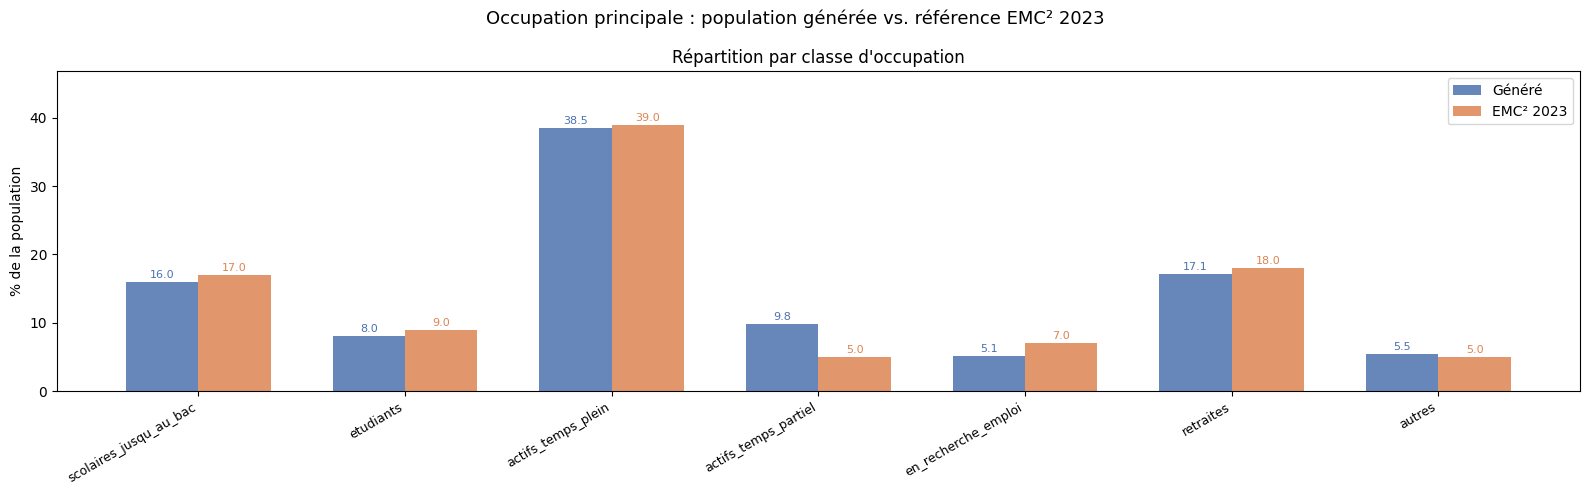


=== Secteur d'activité (employment_sector) — actifs uniquement ===

Secteur                                              N       %
------------------------------------------------------------
  Admin. pub. / Éducation / Santé                  139   28.2%
  Sci. tech. / Services aux entr.                   80   16.2%
  Commerce / Auto                                   69   14.0%
  Construction / BTP                                32    6.5%
  Info. / Communication                             30    6.1%
  Transport / Entreposage                           27    5.5%
  Arts / Loisirs / Autres services                  26    5.3%
  Finance / Assurance                               19    3.9%
  Industrie diverse                                 17    3.4%
  Hôtellerie / Restauration                         14    2.8%
  Équipement de transport                           13    2.6%
  Agriculture                                       10    2.0%
  Immobilier                                       

In [ ]:
# ── Comparaison avec la référence EMC² 2023 ──────────────────────────────────
ref_path = REPO_ROOT / "scripts" / "data" / "population" / "population_emc2_2023.yaml"
with open(ref_path, encoding="utf-8") as f:
    ref = yaml.safe_load(f)

ref_occ = ref["enquete"]["repartition_par_occupation_principale"]
ref_series = pd.Series({c: ref_occ[c] for c in EMC2_OCC_CLASSES}, name="EMC² 2023 (%)")

gen_series = pd.Series(
    {c: occ_counts[c] / total * 100 for c in EMC2_OCC_CLASSES},
    name=f"Généré (%) — {COMPARE_FILE}",
)

cmp_df = pd.concat([gen_series, ref_series], axis=1)
cmp_df["Δ (pp)"] = (cmp_df.iloc[:, 0] - cmp_df.iloc[:, 1]).round(1)
cmp_df = cmp_df.round(1)
print("=== Occupation principale — Généré vs. EMC² 2023 ===\n")
print(cmp_df.to_string())

# ── Graphique comparatif ───────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(16, 5))
fig.suptitle("Occupation principale : population générée vs. référence EMC² 2023", fontsize=13)

x    = np.arange(len(EMC2_OCC_CLASSES))
w    = 0.35
clrs = ["#4C72B0", "#DD8452"]

b1 = ax.bar(x - w/2, gen_series.values,  w, label="Généré",     color=clrs[0], alpha=0.85)
b2 = ax.bar(x + w/2, ref_series.values,  w, label="EMC² 2023",  color=clrs[1], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(EMC2_OCC_CLASSES, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("% de la population")
ax.set_title("Répartition par classe d'occupation")
ax.legend()
ax.set_ylim(0, max(gen_series.max(), ref_series.max()) * 1.2)
for b in b1:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
            f"{b.get_height():.1f}", ha="center", va="bottom", fontsize=8, color=clrs[0])
for b in b2:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
            f"{b.get_height():.1f}", ha="center", va="bottom", fontsize=8, color=clrs[1])

# # Écarts (Δ)
# ax2 = axes[1]
# deltas = cmp_df["Δ (pp)"].values
# colors_delta = ["#C44E52" if d < 0 else "#55A868" for d in deltas]
# ax2.bar(x, deltas, color=colors_delta, alpha=0.85)
# ax2.axhline(0, color="black", linewidth=0.8)
# ax2.set_xticks(x)
# ax2.set_xticklabels(EMC2_OCC_CLASSES, rotation=30, ha="right", fontsize=9)
# ax2.set_ylabel("Écart (pp)")
# ax2.set_title("Écart Généré − EMC² (points de %)")
# for i, (bar, val) in enumerate(zip(ax2.patches, deltas)):
#     ax2.text(bar.get_x() + bar.get_width()/2,
#              val + (0.3 if val >= 0 else -0.6),
#              f"{val:+.1f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

# ── Distribution de employment_sector parmi les actifs ───────────────────────
print("\n=== Secteur d'activité (employment_sector) — actifs uniquement ===\n")
sector_counts: dict[str, int] = defaultdict(int)
for entry in sample_data:
    t   = entry["identity"]["traits_json"]
    cls = map_occupation_emc2(t)
    if cls in ("actifs_temps_plein", "actifs_temps_partiel"):
        sec = t.get("employment_sector", "") or "inconnu"
        sector_counts[sec] += 1

n_actifs = sum(sector_counts.values())
print(f"{'Secteur':<48} {'N':>5}  {'%':>6}")
print("-" * 60)
for sec, cnt in sorted(sector_counts.items(), key=lambda x: -x[1]):
    label = EMPLOYMENT_SECTOR_LABELS.get(sec, sec or "inconnu")
    print(f"  {label:<46} {cnt:>5}  {cnt/n_actifs*100:>5.1f}%")

## Section 8 — Catégorisation de l'occupation principale (EMC² 7 classes)

Mapping des champs `main_occupation` → `professional_activity` → règles sur `age`/`employed`/`studies`
vers les 7 classes EMC² :

| Classe EMC²             | Critère principal                                      |
|-------------------------|--------------------------------------------------------|
| `scolaires_jusqu_au_bac`| main_occ = "Scolaire" **ou** prof_act = "Child/Student < 18 ans" |
| `etudiants`             | main_occ = "Étudiant" **ou** prof_act = "Student ≥ 18 ans"       |
| `actifs_temps_plein`    | main_occ = "Travail à plein temps" / "Full-Time Worker"          |
| `actifs_temps_partiel`  | main_occ = "Travail à temps partiel" / "Part-Time Worker"        |
| `en_recherche_emploi`   | main_occ = "Chômeur/recherche d'emploi" / "Unemployed"           |
| `retraites`             | main_occ = "Retraité" / "Retired"                                |
| `autres`                | Personne au foyer, Other Inactive, Homemaker, …                  |